<a href="https://colab.research.google.com/github/Poonam4385/Deep-learning/blob/main/Cat_Dog_Classification_using_CNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: import required Lib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy



In [ ]:
# Step 2: Downlaod the Dataset
import kagglehub
import shutil
import os

# Dataset ID
dataset = "birajsth/cats-and-dogs-filtered"

# Download dataset
download_path = kagglehub.dataset_download(dataset)

# Destination path
save_path = "/content/Dataset"

# Create destination folder
os.makedirs(save_path, exist_ok=True)

# Copy downloaded dataset to /content/Dataset
shutil.copytree(download_path, save_path, dirs_exist_ok=True)

print("Dataset downloaded successfully!")
print("Saved at:", save_path)
print("Files:", os.listdir(save_path))

Using Colab cache for faster access to the 'cats-and-dogs-filtered' dataset.
Dataset downloaded successfully!
Saved at: /content/Dataset
Files: ['cats_and_dogs_filtered']


In [ ]:
# Path of datasets
base_data_dir = os.path.join(save_path, 'cats_and_dogs_filtered')

In [ ]:
# Step 3: Make directory of training and testing

train_dir = os.path.join(base_data_dir, 'train')
validation_dir = os.path.join(base_data_dir, 'validation')

In [ ]:
# Step 4: Make the Train cat,dog directory and validation cat and dog directory

train_cat_dir = os.path.join(train_dir, 'cats')
train_dog_dir = os.path.join(train_dir, 'dogs')
validation_cat_dir = os.path.join(validation_dir, 'cats')
validation_dog_dir = os.path.join(validation_dir, 'dogs')


In [ ]:
# Step 5: Check the len of train and validation cat and dog
num_cat_train = len(os.listdir(train_cat_dir))
num_dog_train = len(os.listdir(train_dog_dir))
num_cat_validation = len(os.listdir(validation_cat_dir))
num_dog_validation = len(os.listdir(validation_dog_dir))

total_train = num_cat_train + num_dog_train
total_val = num_cat_validation + num_dog_validation

In [ ]:
# Step 5: print all length
print("Total training cat images:", num_cat_train)
print("Total training dog images:", num_dog_train)
print("Total validation cat images:", num_cat_validation)
print("Total validation dog images:", num_dog_validation)

Total training cat images: 1000
Total training dog images: 1000
Total validation cat images: 500
Total validation dog images: 500


In [ ]:
# Step 5: Take the Hyperparamter
batch_size = 128
epochs = 5
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [ ]:
# Step 6: Data Augmentation
train_image_generator = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# validation
validation_image_generator = ImageDataGenerator(rescale=1. / 255)


In [ ]:
# Step 6: Creare the flow directory

train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


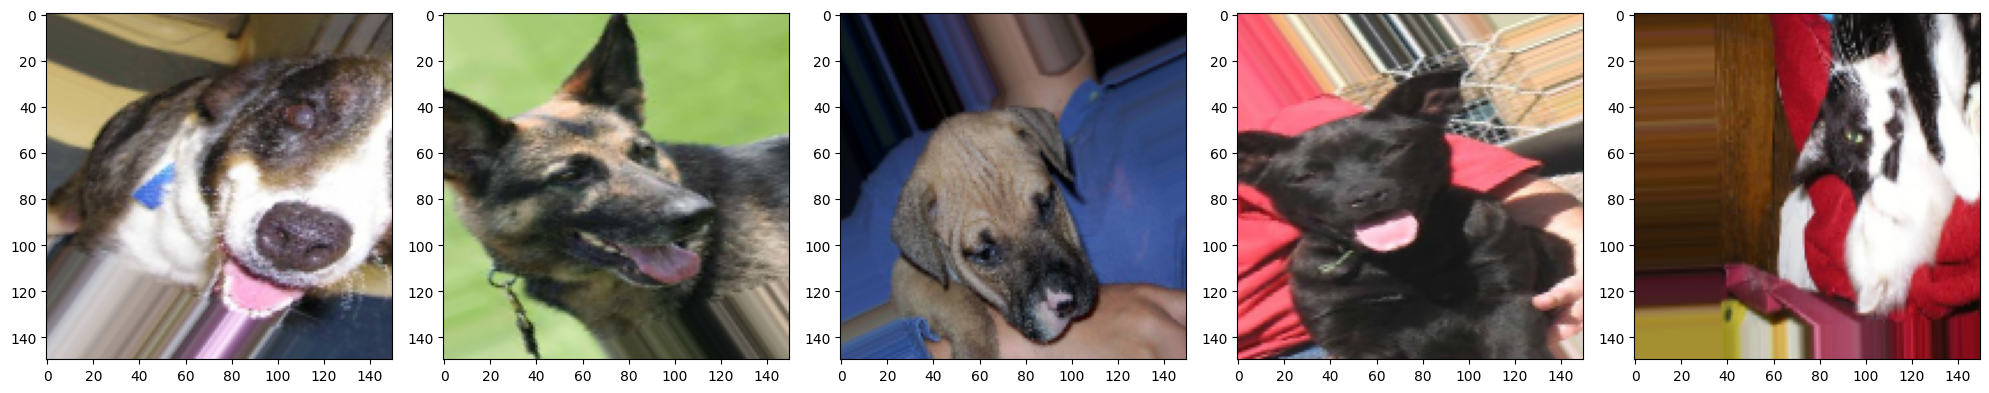

In [ ]:
# show the sample of training data

sample_training_imges, _ = next(train_data_gen)

# make the function to plot the images in the form grid
#with 1 rows and 5 columns where images are placed in each column.


def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

plotImages(sample_training_imges[:5])




In [ ]:
# Step 8: Building model

model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 9: Model compile

model.compile(optimizer=Adam(learning_rate=0.001),
              loss=BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 10 : Model Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history = model.fit(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=30,
    validation_data=val_data_gen,
    validation_steps=total_val // batch_size,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5272 - loss: 0.7638 - val_accuracy: 0.5078 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/30
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5391 - loss: 0.6906

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.5391 - loss: 0.6906 - val_accuracy: 0.5045 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 966ms/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.4933 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.5045 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 982ms/step - accuracy: 0.5016 - loss: 0.6907 - val_accuracy: 0.5056 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.4766 - loss: 0.6934 - val_accuracy: 0.5011 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5048 - loss: 0.6875 - val_accuracy: 0.5033 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.4297 - loss: 0.6960 - val_accurac

In [16]:
# Step 11: Model matrics display
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

#print
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Loss:", train_loss)
print("Validation Loss:", val_loss)


Training Accuracy: [0.5272436141967773, 0.5390625, 0.5, 0.5, 0.5016025900840759, 0.4765625, 0.504807710647583, 0.4296875, 0.5032051205635071, 0.453125, 0.4962606728076935, 0.5625, 0.5405982732772827, 0.546875, 0.5715811848640442, 0.53125, 0.5625, 0.5546875, 0.5758547186851501, 0.5625, 0.5924145579338074, 0.5703125, 0.5721153616905212, 0.703125, 0.567307710647583, 0.6328125, 0.5956196784973145, 0.546875, 0.6073718070983887, 0.578125]
Validation Accuracy: [0.5078125, 0.5044642686843872, 0.4933035671710968, 0.5044642686843872, 0.5055803656578064, 0.5011160969734192, 0.5033482313156128, 0.4944196343421936, 0.4977678656578064, 0.4944196343421936, 0.5189732313156128, 0.5290178656578064, 0.5803571343421936, 0.5602678656578064, 0.5725446343421936, 0.5837053656578064, 0.5848214030265808, 0.578125, 0.5915178656578064, 0.6194196343421936, 0.6316964030265808, 0.6104910969734192, 0.6417410969734192, 0.6450892686843872, 0.6417410969734192, 0.6462053656578064, 0.6026785969734192, 0.625, 0.65066963434

Text(0.5, 1.0, 'Training and Validation Accuracy')

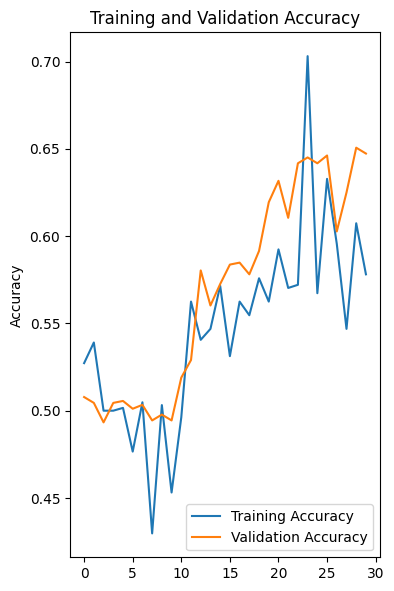

In [21]:
# make plot of accuracy of training and validation
plt.figure(figsize=(4,15))
plt.subplot(2, 1, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')

plt.title('Training and Validation Accuracy')


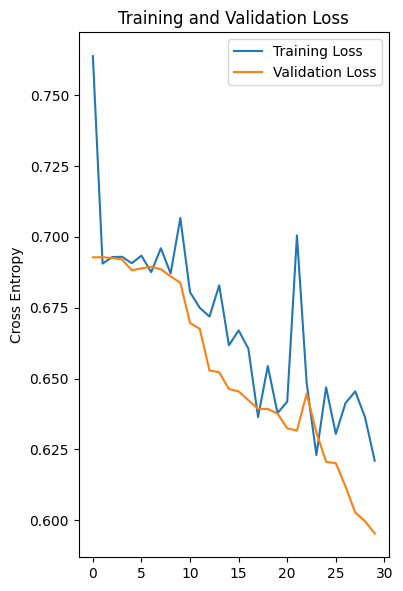

In [22]:
# make the plot for validation loss
plt.figure(figsize=(4, 15))
plt.subplot(2, 1, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.show()

In [24]:
# save the model
model.save('model.h5')

In [29]:
# step 12: prediction and tedting
path = "/content/dog1.jpg"

from keras.models import load_model
import cv2

model = load_model('model.h5')

img = cv2.imread(path)
img = cv2.resize(img, (150, 150))

y_hat = model.predict(np.expand_dims(img, axis=0))

if y_hat > 0.5:
  print("Dog")

else:
  print("Cat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
Dog
